In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#importing dataset using pandas
rs_df = pd.read_csv("retail_store_sales.csv")

In [3]:
rs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [4]:
rs_df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [5]:
#how data looks 
rs_df.head(5)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [6]:
#checking for null values
rs_df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [7]:
#checking duplicates
rs_df.duplicated().sum()

0

In [8]:
#Handling missing values for column 'Price Per Unit'
cond_price = rs_df['Price Per Unit'].isna() & rs_df['Total Spent'].notna() & rs_df['Quantity'].notna()

rs_df.loc[cond_price, 'Price Per Unit'] = rs_df['Total Spent'] / rs_df['Quantity']

print(rs_df[['Price Per Unit', 'Total Spent', 'Quantity']].isnull().sum())

Price Per Unit      0
Total Spent       604
Quantity          604
dtype: int64


In [9]:
rs_df.loc[rs_df['Quantity'].isna(),['Total Spent', 'Price Per Unit', 'Quantity']]

,Total Spent,Price Per Unit,Quantity
7,NaN,33.5,NaN
15,NaN,24.5,NaN
19,NaN,35.0,NaN
25,NaN,39.5,NaN
34,NaN,23.0,NaN
...,...,...,...
12527,NaN,5.0,NaN
12552,NaN,8.0,NaN
12556,NaN,41.0,NaN
12562,NaN,33.5,NaN


In [10]:
#dropping the rows where both 'Quantity' and 'Total Spent' are missing
rs_df = rs_df.dropna(subset = ['Quantity', 'Total Spent'],how = 'all')

In [11]:
rs_df.head(5)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [12]:
#checked category whether its standard or not
rs_df['Category'].unique()

array(['Patisserie', 'Milk Products', 'Butchers', 'Beverages', 'Food',
       'Furniture', 'Electric household essentials',
       'Computers and electric accessories'], dtype=object)

In [13]:
rs_df = rs_df.copy()

In [14]:
#changed date to datetime format
rs_df['Transaction Date'] = pd.to_datetime(rs_df['Transaction Date'])

print(rs_df['Transaction Date'].dtype)

datetime64[ns]


In [15]:
rs_df['Transaction Date'].isna().sum()

0

In [16]:
#checked the tota spent is calculated correctly or not
rs_df['Calculated Total Spent'] = rs_df['Quantity'] * rs_df['Price Per Unit']

In [17]:
rs_df[['Total Spent', 'Calculated Total Spent']].head(20)

,Total Spent,Calculated Total Spent
0,185.0,185.0
1,261.0,261.0
2,43.0,43.0
3,247.5,247.5
4,87.5,87.5
5,200.0,200.0
6,40.0,40.0
8,27.5,27.5
9,109.5,109.5
10,72.0,72.0


In [18]:
rs_df['Total Spent Correct'] = (rs_df['Total Spent'].sub(rs_df['Calculated Total Spent']).abs() < 0.01)

In [19]:
print(rs_df['Total Spent Correct'].value_counts())

True    11971
Name: Total Spent Correct, dtype: int64


In [20]:
#checked 'Category' column for null values
rs_df['Category'].isna().sum()

0

In [21]:
rs_df['Item'].isna().sum()

609

In [22]:
rs_df.loc[rs_df['Item'].isna(),['Category', 'Price Per Unit', 'Quantity', 'Item']].head(20)

,Category,Price Per Unit,Quantity,Item
5,Patisserie,20.0,10.0,NaN
11,Milk Products,6.5,8.0,NaN
17,Milk Products,27.5,10.0,NaN
21,Milk Products,35.0,3.0,NaN
32,Food,24.5,8.0,NaN
127,Butchers,27.5,10.0,NaN
159,Butchers,14.0,9.0,NaN
216,Patisserie,5.0,8.0,NaN
247,Electric household essentials,21.5,7.0,NaN
271,Milk Products,11.0,9.0,NaN


In [23]:
rs_df.groupby('Category')['Item'].nunique()

Category
Beverages                             25
Butchers                              25
Computers and electric accessories    25
Electric household essentials         25
Food                                  25
Furniture                             25
Milk Products                         25
Patisserie                            25
Name: Item, dtype: int64

In [24]:
rs_df.groupby('Category')['Item'].unique()

Category
Beverages                             [Item_16_BEV, Item_7_BEV, Item_25_BEV, Item_11...
Butchers                              [Item_12_BUT, Item_22_BUT, Item_3_BUT, Item_20...
Computers and electric accessories    [Item_16_CEA, Item_5_CEA, Item_15_CEA, Item_24...
Electric household essentials         [Item_13_EHE, Item_4_EHE, Item_21_EHE, Item_10...
Food                                  [Item_6_FOOD, Item_1_FOOD, Item_2_FOOD, Item_1...
Furniture                             [Item_16_FUR, Item_14_FUR, Item_25_FUR, Item_1...
Milk Products                         [Item_17_MILK, nan, Item_16_MILK, Item_19_MILK...
Patisserie                            [Item_10_PAT, nan, Item_24_PAT, Item_17_PAT, I...
Name: Item, dtype: object

In [25]:
keys = list(zip(rs_df['Category'], rs_df['Price Per Unit']))

In [26]:
rs_df.groupby(['Category', 'Price Per Unit'])['Item'].nunique()

Category    Price Per Unit
Beverages   5.0               1
            6.5               1
            8.0               1
            9.5               1
            11.0              1
                             ..
Patisserie  35.0              1
            36.5              1
            38.0              1
            39.5              1
            41.0              1
Name: Item, Length: 200, dtype: int64

In [27]:
rs_df.loc[rs_df['Item'].isna(),['Category', 'Price Per Unit', 'Quantity', 'Item']].head(20)

,Category,Price Per Unit,Quantity,Item
5,Patisserie,20.0,10.0,NaN
11,Milk Products,6.5,8.0,NaN
17,Milk Products,27.5,10.0,NaN
21,Milk Products,35.0,3.0,NaN
32,Food,24.5,8.0,NaN
127,Butchers,27.5,10.0,NaN
159,Butchers,14.0,9.0,NaN
216,Patisserie,5.0,8.0,NaN
247,Electric household essentials,21.5,7.0,NaN
271,Milk Products,11.0,9.0,NaN


In [28]:
item_map = (rs_df.dropna(subset = ['Item'])
           .drop_duplicates(['Category', 'Price Per Unit'])
           .set_index(['Category', 'Price Per Unit'])
           ['Item'].to_dict()
           )

In [29]:
rs_df['Item'] = rs_df['Item'].fillna(pd.Series(keys, index = rs_df.index).map(item_map))

In [30]:
print("remaining Missing Items : ", rs_df['Item'].isna().sum())

remaining Missing Items :  0


In [31]:
rs_df.isna().sum()

Transaction ID               0
Customer ID                  0
Category                     0
Item                         0
Price Per Unit               0
Quantity                     0
Total Spent                  0
Payment Method               0
Location                     0
Transaction Date             0
Discount Applied          3988
Calculated Total Spent       0
Total Spent Correct          0
dtype: int64

'Discount Applied' appears to be a flag/indicator column,not a value used to calculate revenue.I am keeping this column same as it is as there's not enough inforamtion present that shows relation between Total Spent and 'Discount Applied' or 'Price Per Unit' and 'Discount Applied'.

# EDA

In [32]:
#Categorical Analysis
sales_by_cat = rs_df.groupby('Category')['Total Spent'].sum().sort_values(ascending = False)


Category
Butchers                              208118.0
Electric household essentials         203813.5
Beverages                             197047.5
Furniture                             195310.0
Food                                  194812.0
Computers and electric accessories    190692.5
Patisserie                            182165.5
Milk Products                         180112.0
Name: Total Spent, dtype: float64

Text(0.5, 1.0, 'Top Categories')

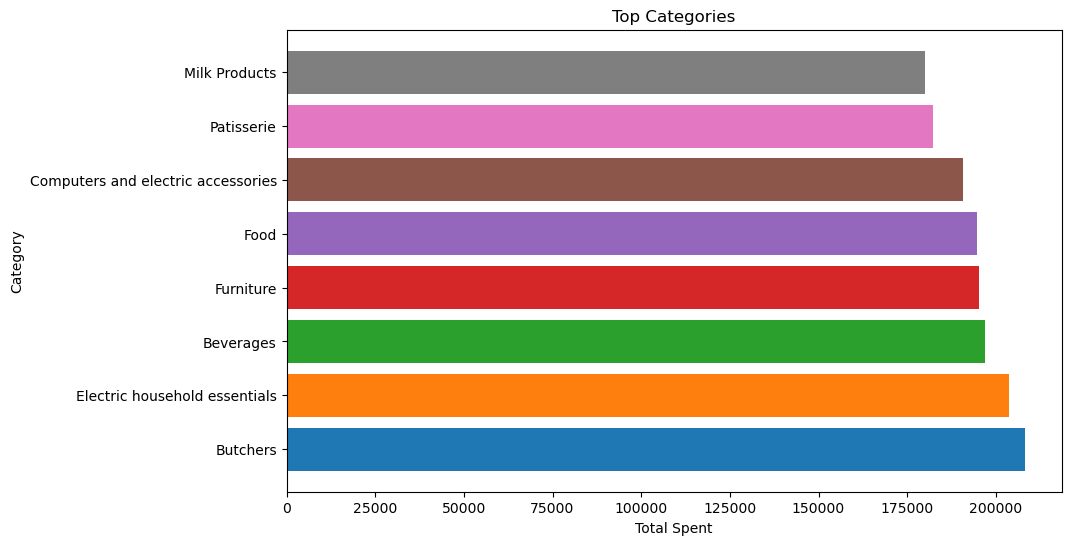

In [61]:
#visualizing top items using horizontal bar chart
plt.figure(figsize = (10, 6))
plt.barh(sales_by_cat.index, sales_by_cat.values, color = plt.cm.tab10(range(len(sales_by_cat))))

plt.xlabel('Total Spent')
plt.ylabel('Category')
plt.title('Top Categories')

# Key insights

Butchers generated the highest total sales, followed closely by Electric household essentials and Beverages.

Milk Products had the lowest sales among the top categories, but overall sales were fairly close across these categories.

# Yearly Analysis

In [36]:
#deriving year from date
rs_df['Year'] = rs_df["Transaction Date"].dt.year

yearly_sales  = rs_df[rs_df['Year']!= 2025].groupby('Year')['Total Spent'].sum()
yearly_sales

Year
2022    510329.5
2023    491312.0
2024    524881.0
Name: Total Spent, dtype: float64

In yearly analysis,I have not included 2025 as it has only January data.

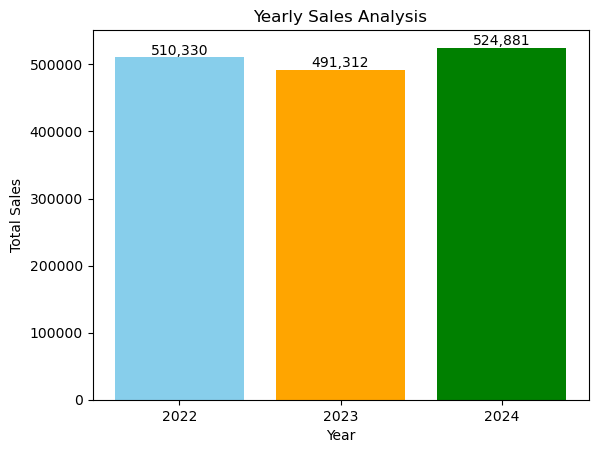

In [37]:
#ploting bar chart for yearly sales
bars = plt.bar(yearly_sales.index, yearly_sales.values, color = ['skyblue', 'orange', 'green'])
plt.title("Yearly Sales Analysis")
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(yearly_sales.index)

for bar in bars:
    value =  bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, value, f'{value:,.0f}', ha = 'center', va = 'bottom')
plt.show()

# Key insights

2024 had the highest total sales at about 524,881, showing strong growth compared with the previous year.

Sales decreased slightly in 2023 to around 491,312, before rising significantly in 2024.

Overall, the business shows a positive sales trend, with 2024 performing the best among the three years.

# Monthly Analysis

In [52]:
#deriving month from date
rs_df['Month'] = rs_df["Transaction Date"].dt.month_name()
#monthly sales analysis and excluding January 2025
monthly_sales  = rs_df[rs_df['Year'] != 2025].groupby('Month')['Total Spent'].sum().sort_values(ascending = False)
monthly_sales

Month
January      148872.5
July         131509.0
June         129771.0
December     129688.5
September    129344.0
April        125618.5
May          124594.5
August       123287.5
March        122392.0
November     122346.5
February     119685.0
October      119413.5
Name: Total Spent, dtype: float64

# Monthly Analysis By Year

In [47]:
yearly_monthly_sales  = rs_df.groupby(['Year', 'Month'])['Total Spent'].sum().unstack()
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
yearly_monthly_sales = yearly_monthly_sales.reindex(columns = month_order)

yearly_monthly_sales

Month,January,February,March,April,May,June,July,August,September,October,November,December
Year,,,,,,,,,,,,
2022,52911.5,43325.5,40996.0,40442.0,40347.5,42576.0,44471.5,41333.5,46113.5,38355.0,41256.5,38201.0
2023,48052.5,39214.5,38534.5,38905.5,40480.5,42474.0,45632.5,38592.0,41069.0,38322.0,37014.0,43021.0
2024,47908.5,37145.0,42861.5,46271.0,43766.5,44721.0,41405.0,43362.0,42161.5,42736.5,44076.0,48466.5
2025,25548.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


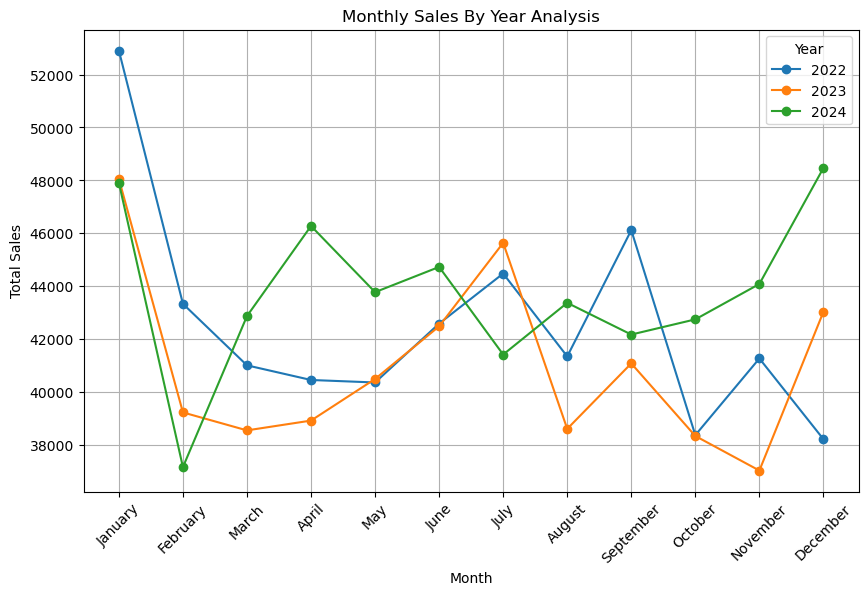

In [49]:
#monthly analysis by year 
yearly_monthly_sales = yearly_monthly_sales.drop(index = 2025, errors = 'ignore')
plt.figure(figsize = (10, 6))

for year in yearly_monthly_sales.index:
    plt.plot(yearly_monthly_sales.columns, yearly_monthly_sales.loc[year], marker = 'o', label = str(year))

plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales By Year Analysis')
plt.xticks(rotation = 45)
plt.legend(title = 'Year')
plt.grid(True)
plt.show()

2025 data only covers January and shows unusually low sales compared to other years' January totals — well below what a complete month would typically show given the seasonal pattern. This suggests the 2025 data is incomplete rather than reflecting an actual sales decline, so 2025 is excluded from both the yearly and monthly-by-year analysis to avoid misrepresenting the trend.

# Key insights

January shows a strong seasonal pattern, with sales starting high in all three years, while February tends to be weaker, especially in 2024.

Sales generally strengthen toward the end of the year, with December showing strong performance, particularly in 2024.

Overall, sales fluctuate throughout the year, with mid-year peaks and noticeable dips around February and October–November.

# Payment Method Analysis

In [58]:
payment_met_analysis = rs_df.groupby('Payment Method').agg(
    Revenue = ('Total Spent', 'sum'),
    Transaction_Volume = ('Total Spent', 'count')
)
payment_met_analysis

,Revenue,Transaction_Volume
Payment Method,,
Cash,537710.0,4103
Credit Card,507082.0,3927
Digital Wallet,507279.0,3941


Cash is the top performer, driving the highest sales ($537.7K) and transaction volume (4,103).

Credit cards and digital wallets run virtually neck-and-neck, each bringing in around $507K across ~3,930 transactions.

Average customer spending stays virtually identical at roughly $130 per order, regardless of the payment method used.

# Category Sales By Location

In [42]:
#location analysis to find which item sells online or in-store
location_sales = rs_df.groupby(['Category', 'Location'])['Total Spent'].sum().unstack(fill_value = 0)

location_sales

Location,In-store,Online
Category,,
Beverages,98026.0,99021.5
Butchers,101777.0,106341.0
Computers and electric accessories,87323.5,103369.0
Electric household essentials,97778.5,106035.0
Food,95926.0,98886.0
Furniture,99611.0,95699.0
Milk Products,88813.0,91299.0
Patisserie,91415.0,90750.5


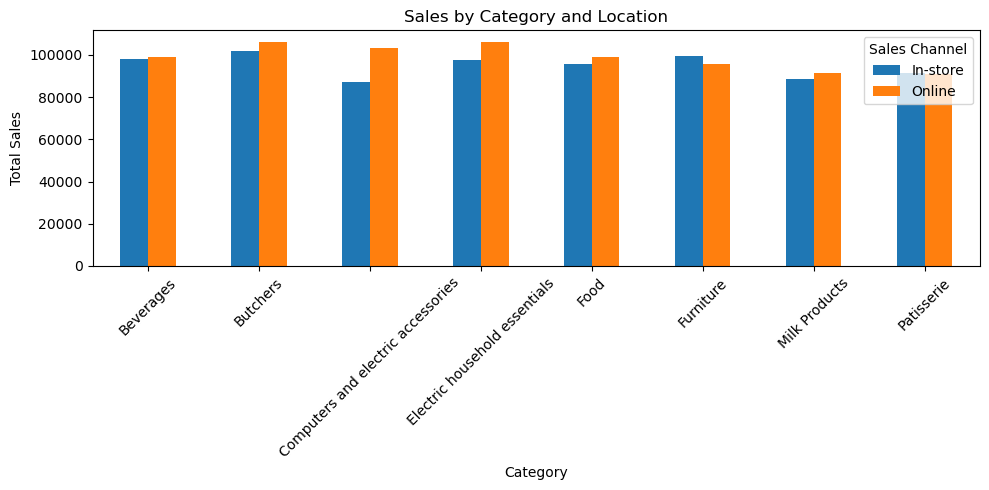

In [43]:
#ploting bar chart to visualize category sales by location
location_sales.plot(kind = 'bar', figsize = (10, 5))

plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.title('Sales by Category and Location')

plt.xticks(rotation = 45)
plt.legend(title = 'Sales Channel')
plt.tight_layout()

plt.show()

# Key insights

Online sales are higher than in-store sales in most categories, especially Butchers, Computers & electric accessories, and Electric household essentials.

Furniture is the only category where in-store sales are slightly higher than online sales.

Overall, the sales channels are fairly balanced, but online shopping performs slightly better across most categories.

# Conclusion

Overall, the retail store shows strong and improving sales performance, with 2024 achieving the highest yearly sales. The analysis shows clear seasonal fluctuations, with stronger sales in January and toward the end of the year. Online sales generally perform better than in-store sales, while some categories such as Butchers and Electric household essentials are among the stronger performers. These insights can help the business focus on high-performing categories, strengthen online sales, and plan inventory around seasonal demand.